2026-04-06 12:02:31.039797: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775476951.256657      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775476951.318549      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775476951.837414      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775476951.837463      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775476951.837469      55 computation_placer.cc:177] computation placer alr

Train: 7010  |  Test: 3005
label
nv       4693
mel       779
bkl       769
bcc       360
akiec     229
vasc       99
df         81
Name: count, dtype: int64
Found 7010 validated image filenames belonging to 7 classes.
Found 3005 validated image filenames belonging to 7 classes.


I0000 00:00:1775476988.495217      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1775476988.501350      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "MTA_Net"

...

 44/110 ━━━━━━━━━━━━━━━━━━━━ 2:12 2s/step - accuracy: 0.5390 - loss: 1.6550

2026-04-06 12:08:49.312133: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-06 12:08:49.451717: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-06 12:08:50.359004: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-06 12:08:50.505131: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-06 12:08:51.289252: E external/local_xla/xla/stream_

110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.6222 - loss: 1.2686

2026-04-06 12:13:14.457523: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-06 12:13:14.598475: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-06 12:13:15.550727: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-06 12:13:15.712878: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-06 12:13:16.530549: E external/local_xla/xla/stream_


Epoch 1: val_accuracy improved from -inf to 0.05624, saving model to mta_net_best.keras
110/110 ━━━━━━━━━━━━━━━━━━━━ 610s 4s/step - accuracy: 0.6229 - loss: 1.2653 - val_accuracy: 0.0562 - val_loss: 2.7866 - learning_rate: 1.0000e-04
Epoch 2/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7988 - loss: 0.5519
Epoch 2: val_accuracy improved from 0.05624 to 0.13844, saving model to mta_net_best.keras
110/110 ━━━━━━━━━━━━━━━━━━━━ 145s 1s/step - accuracy: 0.7988 - loss: 0.5519 - val_accuracy: 0.1384 - val_loss: 3.2106 - learning_rate: 1.0000e-04
Epoch 3/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8236 - loss: 0.4806
Epoch 3: val_accuracy improved from 0.13844 to 0.60300, saving model to mta_net_best.keras
110/110 ━━━━━━━━━━━━━━━━━━━━ 146s 1s/step - accuracy: 0.8237 - loss: 0.4806 - val_accuracy: 0.6030 - val_loss: 1.0648 - learning_rate: 1.0000e-04
Epoch 4/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8490 - loss: 0.4177
Epoch 4: val_accuracy improved from 

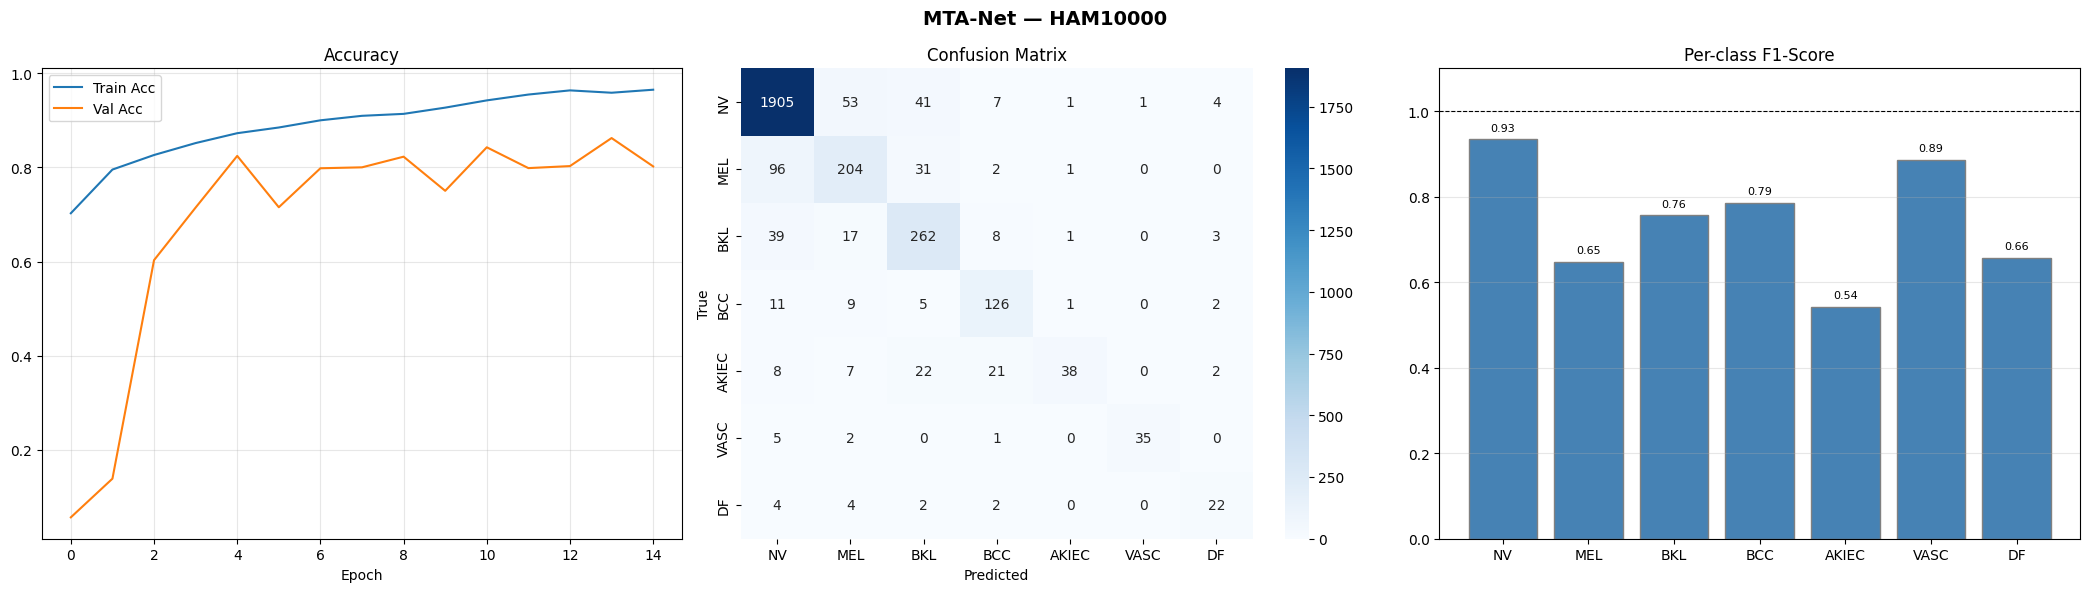


✅  Baseline complete. Ready for novel extensions.


In [1]:
# ══════════════════════════════════════════════════════════════════════════════
#  MTA-Net: Multi-scale Triplet Attention-aware Network
#  Gajera et al., Computers in Biology and Medicine, 2025
#  HAM10000 · DenseNet121 backbone · Single Notebook Cell
# ══════════════════════════════════════════════════════════════════════════════

import os, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import (confusion_matrix, classification_report,
                              accuracy_score, cohen_kappa_score,
                              matthews_corrcoef)
import tensorflow as tf
import keras
from keras import layers, Model, ops
from keras.applications import DenseNet121
from tensorflow.keras.preprocessing.image import ImageDataGenerator  # tf.keras still has it
from keras.optimizers import Nadam
from keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint

warnings.filterwarnings('ignore')
random.seed(42); np.random.seed(42); tf.random.set_seed(42)

# ─────────────────────────────────────────────────────────────────────────────
# 0.  CONFIG
# ─────────────────────────────────────────────────────────────────────────────
IMG_SIZE       = 224
BATCH_SIZE     = 64
EPOCHS         = 50
LR             = 1e-4
DROPOUT        = 0.25
DILATION_RATES = [1, 2, 3]   # best config per Table 6

DATA_DIR  = '/kaggle/input/datasets/vrindaat/ham10000-dataset'
META_PATH = os.path.join(DATA_DIR, 'HAM10000_metadata.csv')
IMG_DIRS  = [os.path.join(DATA_DIR, 'HAM10000_images_part_1'),
             os.path.join(DATA_DIR, 'HAM10000_images_part_2')]

CLASS_NAMES = ['nv','mel','bkl','bcc','akiec','vasc','df']
NUM_CLASSES = len(CLASS_NAMES)

# ─────────────────────────────────────────────────────────────────────────────
# 1.  DATA — 70 : 30 SPLIT
# ─────────────────────────────────────────────────────────────────────────────
meta = pd.read_csv(META_PATH)
meta['label'] = meta['dx']

img_lookup = {}
for d in IMG_DIRS:
    for f in os.listdir(d):
        img_lookup[os.path.splitext(f)[0]] = os.path.join(d, f)

meta['path']      = meta['image_id'].map(img_lookup)
meta['label_idx'] = meta['label'].map({c:i for i,c in enumerate(CLASS_NAMES)})
meta.dropna(subset=['path','label_idx'], inplace=True)

train_df, test_df = train_test_split(meta, test_size=0.30,
                                     random_state=42, stratify=meta['label_idx'])
print(f"Train: {len(train_df)}  |  Test: {len(test_df)}")
print(train_df['label'].value_counts())

# ─────────────────────────────────────────────────────────────────────────────
# 2.  DATA GENERATORS WITH AUGMENTATION  (Section 4.1)
# ─────────────────────────────────────────────────────────────────────────────
flow_args = dict(x_col='path', y_col='label',
                 target_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE,
                 class_mode='categorical', classes=CLASS_NAMES)

train_gen = ImageDataGenerator(
    rescale=1./255, shear_range=0.2, rotation_range=180,
    width_shift_range=0.1, height_shift_range=0.1,
    zoom_range=0.1, horizontal_flip=True, vertical_flip=True,
).flow_from_dataframe(train_df, **flow_args, shuffle=True, seed=42)

test_gen = ImageDataGenerator(rescale=1./255).flow_from_dataframe(
    test_df, **flow_args, shuffle=False)

# ─────────────────────────────────────────────────────────────────────────────
# 3.  BUILDING BLOCKS
# ─────────────────────────────────────────────────────────────────────────────

# ── Helpers: channel-wise reduce ops wrapped as Lambda layers ────────────────
# (keras.ops works on symbolic tensors; tf.* does NOT in Keras 3)
def ch_max(x):
    """Channel-wise max-pool → (H, W, 1)"""
    return layers.Lambda(lambda t: ops.max(t, axis=-1, keepdims=True))(x)

def ch_mean(x):
    """Channel-wise mean-pool → (H, W, 1)"""
    return layers.Lambda(lambda t: ops.mean(t, axis=-1, keepdims=True))(x)


# ── Depth-wise Dilated Conv Block (Eq. 1) ────────────────────────────────────
def dd_conv(x, rate):
    C = x.shape[-1]
    x = layers.DepthwiseConv2D(3, padding='same',
                                dilation_rate=rate, use_bias=False)(x)
    x = layers.Conv2D(C, 1, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    return layers.Activation('relu')(x)


# ── Triplet Spatial Attention — TSA (Fig. 4, Eq. 4-8) ────────────────────────
def tsa(x):
    b1 = ch_max(x)                                              # (H,W,1)

    b2 = layers.DepthwiseConv2D(3, padding='same', use_bias=False)(x)
    b2 = layers.Conv2D(1, 1, padding='same', use_bias=False)(b2) # (H,W,1)

    b3 = ch_mean(x)                                             # (H,W,1)

    attn = layers.Concatenate(axis=-1)([b1, b2, b3])           # (H,W,3)
    attn = layers.Conv2D(1, 1, padding='same', use_bias=False)(attn)
    attn = layers.Activation('sigmoid')(attn)
    return layers.Multiply()([x, attn])


# ── Triplet Channel Attention — TCA (Fig. 5, Eq. 12-16) ──────────────────────
def tca(x):
    C = x.shape[-1]

    b1 = layers.GlobalMaxPooling2D(keepdims=True)(x)             # (1,1,C)

    b2 = layers.Conv2D(C, 1, strides=2, padding='same', use_bias=False)(x)
    b2 = layers.GlobalAveragePooling2D(keepdims=True)(b2)        # (1,1,C)
    b2 = layers.Conv2D(C, 1, padding='same', use_bias=False)(b2)

    b3 = layers.GlobalAveragePooling2D(keepdims=True)(x)         # (1,1,C)

    attn = layers.Concatenate(axis=-1)([b1, b2, b3])            # (1,1,3C)
    attn = layers.Conv2D(C, 1, padding='same', use_bias=False)(attn)
    attn = layers.Activation('sigmoid')(attn)
    return layers.Multiply()([x, attn])


# ── MTSA block (Eq. 2-3) ─────────────────────────────────────────────────────
def mtsa_block(x):
    paths = [tsa(dd_conv(x, r)) for r in DILATION_RATES]
    out   = layers.Add()(paths)        # element-wise sum
    return layers.Add()([out, x])      # skip connection


# ── MTCA block (Eq. 9-11) ────────────────────────────────────────────────────
def mtca_block(x):
    paths = [tca(dd_conv(x, r)) for r in DILATION_RATES]
    out   = layers.Add()(paths)
    return layers.Add()([out, x])


# ── MTA Module: MTSA → MTCA  (Fig. 3, TSA→TCA order per Table 3) ─────────────
def mta_module(x):
    x = mtsa_block(x)
    x = mtca_block(x)
    return x

# ─────────────────────────────────────────────────────────────────────────────
# 4.  BUILD MTA-NET
# ─────────────────────────────────────────────────────────────────────────────
def build_mta_net():
    inputs   = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    backbone = DenseNet121(include_top=False, weights='imagenet',
                           input_tensor=inputs)
    x = mta_module(backbone.output)               # (H', W', 1024)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(DROPOUT)(x)
    out = layers.Dense(NUM_CLASSES, activation='softmax')(x)
    return Model(inputs, out, name='MTA_Net')

model = build_mta_net()
model.summary()

# ─────────────────────────────────────────────────────────────────────────────
# 5.  COMPILE & TRAIN
# ─────────────────────────────────────────────────────────────────────────────
model.compile(optimizer=Nadam(LR),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

callbacks = [
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=5, min_lr=1e-7, verbose=1),
    EarlyStopping(monitor='val_loss', patience=10,
                  restore_best_weights=True, verbose=1),
    ModelCheckpoint('mta_net_best.keras', monitor='val_accuracy',
                    save_best_only=True, verbose=1),
]

history = model.fit(
    train_gen,
    steps_per_epoch  = int(np.ceil(len(train_df) / BATCH_SIZE)),
    validation_data  = test_gen,
    validation_steps = int(np.ceil(len(test_df)  / BATCH_SIZE)),
    epochs=EPOCHS, callbacks=callbacks
)

# ─────────────────────────────────────────────────────────────────────────────
# 6.  EVALUATION
# ─────────────────────────────────────────────────────────────────────────────
model.load_weights('mta_net_best.keras')
test_gen.reset()
n_steps  = int(np.ceil(len(test_df) / BATCH_SIZE))
y_proba  = model.predict(test_gen, steps=n_steps, verbose=1)
y_pred   = np.argmax(y_proba[:len(test_df)], axis=1)
y_true   = test_df['label_idx'].values.astype(int)

acc   = accuracy_score(y_true, y_pred) * 100
kappa = cohen_kappa_score(y_true, y_pred) * 100
mcc   = matthews_corrcoef(y_true, y_pred) * 100

rep   = classification_report(y_true, y_pred,
                               target_names=CLASS_NAMES, output_dict=True)
bmca  = np.mean([rep[c]['recall'] for c in CLASS_NAMES]) * 100
prec  = rep['weighted avg']['precision']  * 100
sens  = rep['weighted avg']['recall']     * 100
f1    = rep['weighted avg']['f1-score']   * 100

print("\n" + "═"*52)
print("      MTA-Net · HAM10000 · Results")
print("═"*52)
for name, val, ref in [
    ("Accuracy",    acc,   91.51),
    ("Precision",   prec,  91.40),
    ("Sensitivity", sens,  91.51),
    ("F1-Score",    f1,    91.44),
    ("Kappa (κ)",   kappa, 83.62),
    ("MCC",         mcc,   83.64),
    ("BMCA",        bmca,  87.18),
]:
    print(f"  {name:<14}: {val:6.2f}%   (paper: {ref:.2f}%)")
print("═"*52)
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=4))

# ─────────────────────────────────────────────────────────────────────────────
# 7.  PLOTS
# ─────────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(21, 6))
fig.suptitle('MTA-Net — HAM10000', fontsize=14, fontweight='bold')

# Training curves
ax = axes[0]
ax.plot(history.history['accuracy'],     label='Train Acc')
ax.plot(history.history['val_accuracy'], label='Val Acc')
ax.set_title('Accuracy'); ax.set_xlabel('Epoch')
ax.legend(); ax.grid(alpha=0.3)

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[c.upper() for c in CLASS_NAMES],
            yticklabels=[c.upper() for c in CLASS_NAMES], ax=axes[1])
axes[1].set_title('Confusion Matrix')
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('True')

# Per-class F1
f1s = [rep[c]['f1-score'] for c in CLASS_NAMES]
axes[2].bar([c.upper() for c in CLASS_NAMES], f1s, color='steelblue', edgecolor='grey')
axes[2].set_ylim(0, 1.1); axes[2].set_title('Per-class F1-Score')
axes[2].axhline(1.0, color='k', linestyle='--', lw=0.8)
for i, v in enumerate(f1s):
    axes[2].text(i, v + 0.02, f'{v:.2f}', ha='center', fontsize=8)
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('mta_net_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✅  Baseline complete. Ready for novel extensions.")